In [68]:
import torch
import mlflow
import ast
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient
import os 
import sys
project_root = os.path.expanduser("~/DLAM-Group6")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from external.xlstm_mixer.xlstm_mixer.models.xlstm_mixer import xLSTMMixer

In [79]:
# Search across both single-step and autoregressive experiments
df_runs = mlflow.search_runs(
    experiment_names=["single_chunk_forecast"]
)

summary_table = df_runs#.sort_values(by="metrics.val_target_mae")
display(summary_table)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.lr,metrics.val_loss,metrics.train_loss,metrics.best_val_loss,...,params.preprocessing.scale_columns,params.data.seq_len,params.data.save_path,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.git.commit,tags.mlflow.source.git.repoURL,tags.mlflow.source.type,tags.mlflow.source.git.branch,tags.mlflow.source.name
0,ab874efe01114e18a05ce06be0214162,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-23 15:58:24.432000+00:00,2026-08-23 18:07:11.034000+00:00,0.000125,0.783100,0.260242,0.645450,...,"['trend', 'workload_intensity', 'promotion_int...",336,experiments/,s2673208,abundant-snail-649,e1e93bdc64183ec45eac2007ba42097b590cb44e,https://github.com/yazidhannachi/DLAM-Group6.git,LOCAL,xlstm-mixer-experiments,src/train.py
1,7f0b259745ec43a589f505747808eba1,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-23 15:54:56.027000+00:00,2026-08-23 18:03:05.949000+00:00,0.000125,0.709895,0.432022,0.672784,...,"['trend', 'workload_intensity', 'promotion_int...",168,experiments/,s2673208,bouncy-elk-491,e1e93bdc64183ec45eac2007ba42097b590cb44e,https://github.com/yazidhannachi/DLAM-Group6.git,LOCAL,xlstm-mixer-experiments,src/train.py
2,e35a116c95ca437e975faeb8f9c209b7,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-23 15:51:01.446000+00:00,2026-08-23 18:22:13.239000+00:00,0.000125,0.673282,0.272254,0.631925,...,"['trend', 'workload_intensity', 'promotion_int...",168,experiments/,s2673208,whimsical-deer-715,e1e93bdc64183ec45eac2007ba42097b590cb44e,https://github.com/yazidhannachi/DLAM-Group6.git,LOCAL,xlstm-mixer-experiments,src/train.py


In [75]:
summary_table[["tags.mlflow.runName","params.model.model_kwargs.seq_len", "params.model.model_kwargs.pred_len"]]

,tags.mlflow.runName,params.model.model_kwargs.seq_len,params.model.model_kwargs.pred_len
0,resilient-snipe-9,None,None
1,resilient-flea-878,None,None
2,dapper-gnat-747,None,None
3,abundant-snail-649,336,24
4,bouncy-elk-491,168,96
5,whimsical-deer-715,168,24


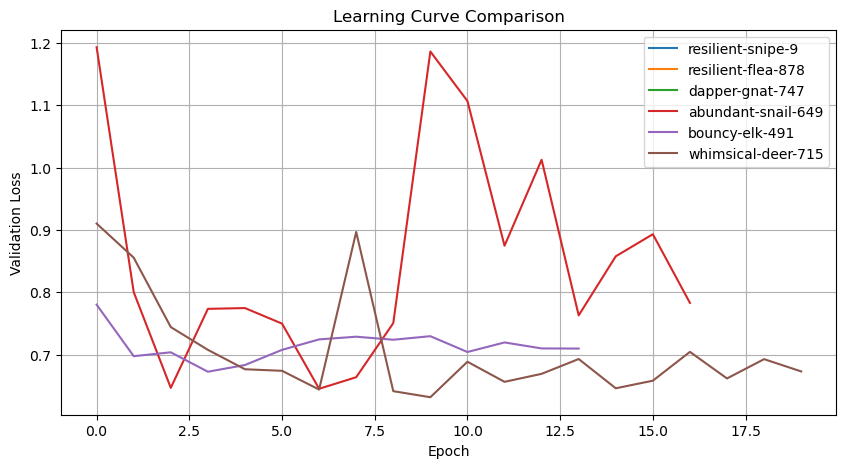

In [70]:
client = MlflowClient()

plt.figure(figsize=(10, 5))

for _, run in summary_table.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    
    history = client.get_metric_history(run_id, "val_loss")
    steps = [m.step for m in history]
    values = [m.value for m in history]
    
    plt.plot(steps, values, label=run_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Learning Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

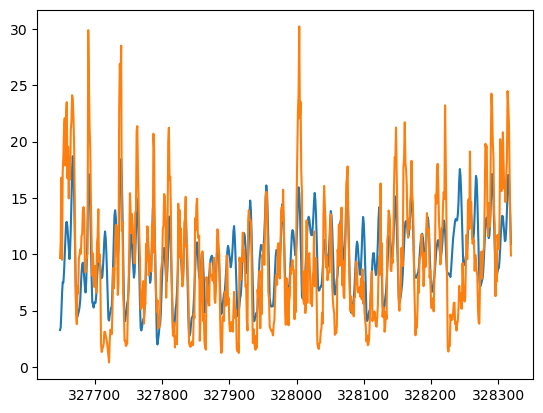

In [67]:
pred_path ="experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/predictions.csv"
target_path = "experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/target.csv"
df_pred = pd.read_csv(pred_path, index_col=0)
df_target = pd.read_csv(target_path, index_col=0)
groups_pred = df_pred.groupby("series_id")
groups_target = df_target.groupby("series_id")
unit_pred = groups_pred.get_group("unit_075")
unit_target = groups_target.get_group("unit_075")

plt.plot(unit_pred["target"])
plt.plot(unit_target["target"])
#plt.savefig("experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/unit_075_preds.png", format='PNG')